Acknowledgement of AI Use - The use of Gen AI was made for this plotting script

In [1]:
import sys
from pathlib import Path

import numpy as np
import matplotlib.pyplot as plt
from scipy.special import ellipj, ellipk, ellipeinc
from scipy.integrate import cumulative_trapezoid

dir_code = Path('.').resolve()
sys.path.insert(0, str(dir_code / 'out'))

import Kerr_geodesics as kgeo
import util

Extremal Kerr $a=M=1$, spherical orbit at $r/M=1.2$, Carter constant $Q/M^2=0.5$.

In [2]:
M = 1.0
a = 1.0   
r = 1.2    
Q = 0.5    

Delta = r**2 - 2*M*r + a**2
Upsilon      = M*r**5 - Q*(r - 3*M)*r**3 + a**2 * Q**2
sqrt_Upsilon = np.sqrt(Upsilon)
Gamma_a      = r**3 * (r - 3*M) - 2*a * (a*Q - sqrt_Upsilon)
denom        = r**2 * np.sqrt(Gamma_a)

E   = (r**3 * (r - 2*M) - a * (a*Q - sqrt_Upsilon)) / denom
Phi = -(2*M*a*r**3 + (r**2 + a**2) * (a*Q - sqrt_Upsilon)) / denom

print(f"E   = {E:.6f}")
print(f"Phi = {Phi:.6f}")

E   = 0.716880
Phi = 1.435709


In [3]:
# Latitudinal roots w1, w2 (cos^2 theta oscillates between 0 and w1)
coeff = a**2 * (1.0 - E**2)
A     = coeff + Q + Phi**2
disc  = np.sqrt(A**2 - 4.0 * coeff * Q)

w1    = (A - disc) / (2.0 * coeff)
w2    = (A + disc) / (2.0 * coeff)

k   = np.sqrt(w1 / w2)
m   = k**2
alp = a * np.sqrt((1.0 - E**2) * w2)

K_val         = ellipk(m)
lambda_period = 4.0 * K_val / alp  # One Quarter of a period times 4

n_periods = 15.0
N_pts     = 300000
lam       = np.linspace(0.0, n_periods * lambda_period, N_pts)

# Theta Analytical
sn_v, cn_v, dn_v, psi_v = ellipj(alp * lam, m)
u_arr    = np.sqrt(w1) * sn_v
theta_an = np.arccos(np.clip(u_arr, -1.0, 1.0))

# Phi Analytical
psi_max  = float(psi_v[-1])
N_fine   = 400_000
psi_fine = np.linspace(0.0, psi_max, N_fine)
sin2_f   = np.sin(psi_fine)**2
intgd    = 1.0 / (
    (1.0 - w1 * sin2_f) *
    np.sqrt(np.maximum(1.0 - m * sin2_f, 1e-15))
)
Pi_fine = np.concatenate([[0.0], cumulative_trapezoid(intgd, psi_fine)])
Pi_arr  = np.interp(psi_v, psi_fine, Pi_fine)

phi_an = (Phi / alp) * Pi_arr + (a / Delta) * (2.0*M*r*E - a*Phi) * lam

#T Analytical
T_r_const = (E * (r**2 + a**2)**2 - 2.0*M*r*a*Phi) / Delta
E_inc     = ellipeinc(psi_v, m)         

t_an = (-a * E * (1.0 - w2) * lam
        - (a * E * w2 / alp) * E_inc
        + T_r_const * lam)

T_coord_period = float(t_an[np.argmin(np.abs(lam - lambda_period))])
print(f"\nCoordinate-time period ≈ {T_coord_period:.3f} M")
print(f"Total analytical time   ≈ {t_an[-1]:.3f} M  ({n_periods} periods)")


Coordinate-time period ≈ 73.125 M
Total analytical time   ≈ 1096.876 M  (15.0 periods)


## Initial condition and numerical integration

For a spherical orbit starting at the equator ($\theta = \pi/2$) moving northward:
- $u_r = 0$ (no radial motion)
- $u_\theta = -\sqrt{Q}$ (covariant $p_\theta$ at the equator; negative = northward)
- $u_\phi = \Phi$ (conserved angular momentum = covariant $p_\phi$)

In [6]:
# x.r, x.th, x.phi, u.r, u.th, u.phi, eps, q_over_m
ic = kgeo.IC(
    r,          
    np.pi/2,    
    0.0,        
    0.0,        
    -np.sqrt(Q),
    Phi,        
    1,          
    0,
)

dt        = 0.005
max_steps = int(np.ceil(n_periods * T_coord_period / dt)) + 2000
domain_L  = 5.0   

geos, geos_meta = kgeo.geodesics_IMR_vacuum(
    M, a,
    dt, max_steps, IMR_max_iters=3, domain_L=domain_L,
    h_rel=1e-5, h_min=1e-6,
    ics=[ic],
)

geo  = np.array(geos[0])  
meta = geos_meta[0]

stop_labels = ['none', 'max_steps', 'invalid_state', 'horizon_entry', 'domain_exit']
print(f"\nSteps taken : {meta.steps}")
print(f"Stop reason : {stop_labels[meta.stop_criterion]}")

x_num = geo[:, 0, :]
u_num = geo[:, 1, :]

r_num   = x_num[:, 0]
th_num  = x_num[:, 1]
phi_num = x_num[:, 2]
t_num   = np.arange(len(r_num)) * dt

print(f"\nr range: [{r_num.min():.6f}, {r_num.max():.6f}]  (should be ~{r})")
print(f"r std  : {r_num.std():.2e}")


Steps taken : 221376
Stop reason : max_steps

r range: [1.200000, 1.200000]  (should be ~1.2)
r std  : 2.28e-08


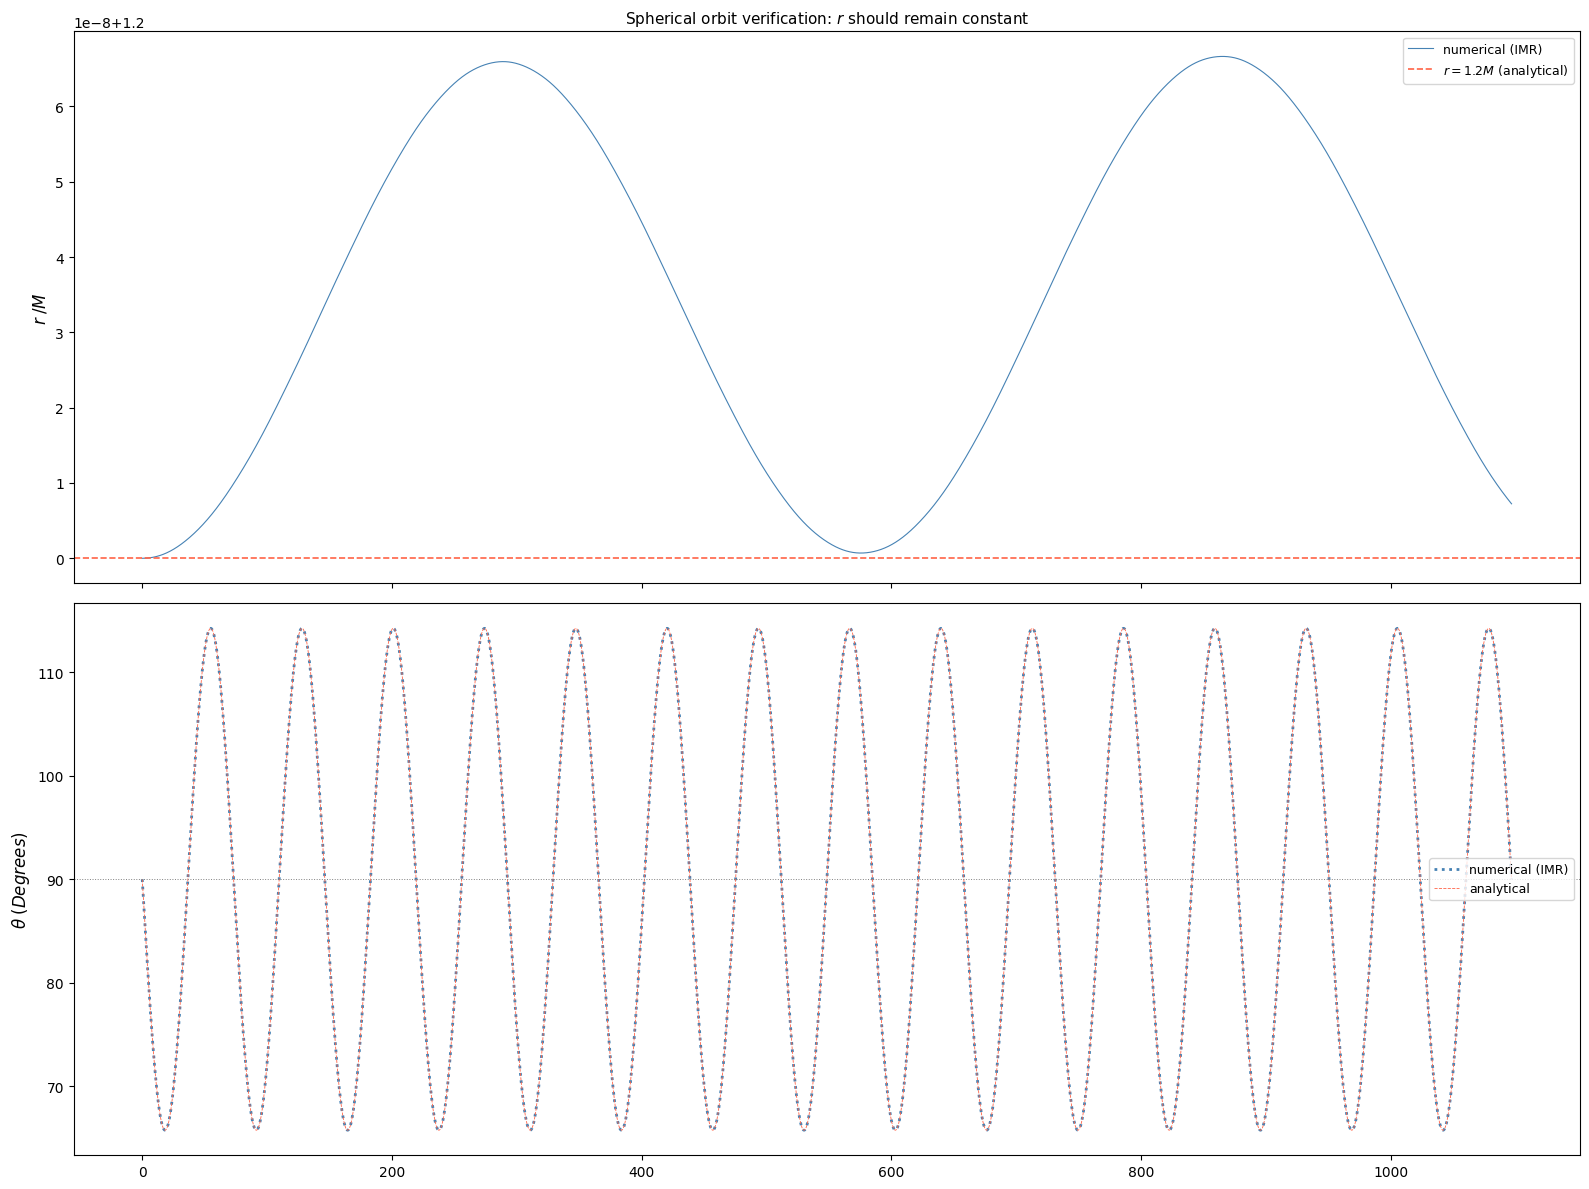

In [8]:
fig, axes = plt.subplots(2, 1, figsize=(16, 12), sharex=True)

T_max_plot = t_an[-1]
mask_num   = t_num <= T_max_plot

# r(t)
ax = axes[0]
ax.plot(t_num[mask_num], r_num[mask_num], color='steelblue', lw=0.8, label='numerical (IMR)')
ax.axhline(r, color='tomato', ls='--', lw=1.2, label=f'$r = {r}M$ (analytical)')
ax.set_ylabel(r'$r\;/M$', fontsize=12)
# ax.set_ylim(r - 0.1, r + 0.1)
ax.legend(fontsize=9)
ax.set_title('Spherical orbit verification: $r$ should remain constant', fontsize=11)

# theta(t)
ax = axes[1]
ax.plot(t_num[mask_num], np.degrees(th_num[mask_num]),
        color='steelblue', lw=2, ls=':', label='numerical (IMR)')
ax.plot(t_an, np.degrees(theta_an),
        color='tomato', ls='--', lw=0.6, label='analytical')
ax.axhline(90.0, color='grey', ls=':', lw=0.7)
ax.set_ylabel(r'$\theta\;(Degrees)$', fontsize=12)
ax.legend(fontsize=9)

plt.tight_layout()
plt.savefig('out/spherical_orbit_coordinates.png', dpi=300, bbox_inches='tight')
plt.show()

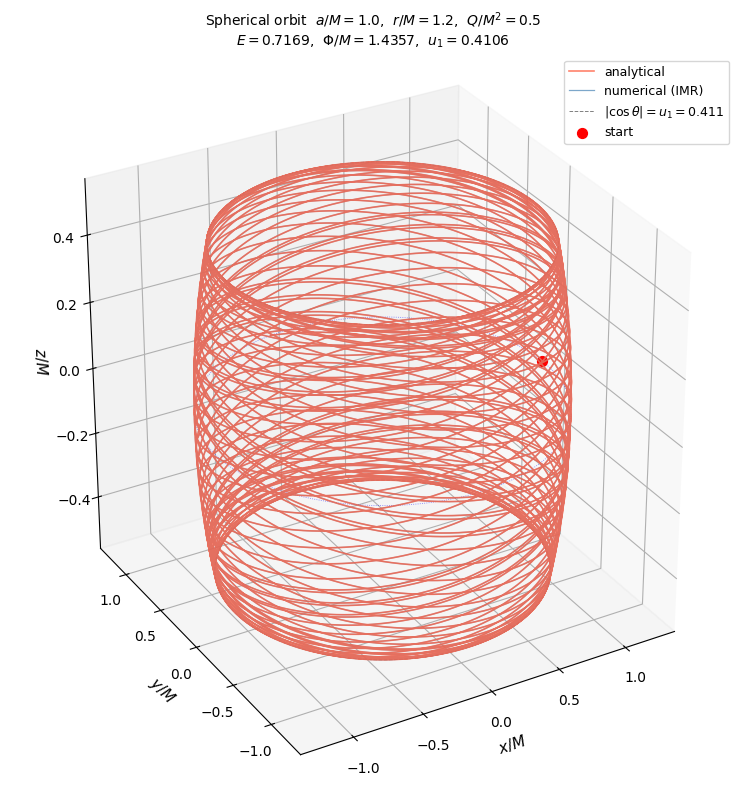

In [ ]:
X_an = r * np.sin(theta_an) * np.cos(phi_an)
Y_an = r * np.sin(theta_an) * np.sin(phi_an)
Z_an = r * np.cos(theta_an)

X_num, Y_num, Z_num = util.sph_to_Car(r_num[mask_num], th_num[mask_num], phi_num[mask_num])

u1       = np.sqrt(w1)
rho_lat  = r * np.sqrt(1 - w1)
lat_circ = np.linspace(0, 2*np.pi, 300)

fig = plt.figure(figsize=(9, 8))
ax  = fig.add_subplot(111, projection='3d', facecolor='white')

ax.plot(X_an,  Y_an,  Z_an,  color='tomato',    lw=1.2, alpha=0.8, label='analytical',      zorder=5)
ax.plot(X_num, Y_num, Z_num, color='steelblue', lw=0.9, alpha=0.7, label='numerical (IMR)', zorder=4)

for sign in (+1, -1):
    ax.plot(
        rho_lat * np.cos(lat_circ),
        rho_lat * np.sin(lat_circ),
        sign * r * u1 * np.ones(300),
        'k--', lw=0.7, alpha=0.5,
        label=fr'$|\cos\theta| = u_1 = {u1:.3f}$' if sign == 1 else '_'
    )


eq = np.linspace(0, 2*np.pi, 300)
ax.plot(r*np.cos(eq), r*np.sin(eq), np.zeros(300), 'b:', lw=0.6, alpha=0.5)


ax.scatter([X_num[0]], [Y_num[0]], [Z_num[0]], color='red', s=50, zorder=10, label='start')

ax.view_init(elev=30, azim=-120)
ax.set_box_aspect([1, 1, 1])
ax.set_xlabel('$x/M$', fontsize=11)
ax.set_ylabel('$y/M$', fontsize=11)
ax.set_zlabel('$z/M$', fontsize=11)
ax.set_title(
    fr'Spherical orbit  $a/M={a/M:.1f}$,  $r/M={r}$,  $Q/M^2={Q}$' + '\n' +
    fr'$E={E:.4f}$,  $\Phi/M={Phi:.4f}$,  $u_1={u1:.4f}$',
    fontsize=10
)
ax.legend(fontsize=9, loc='upper right')
plt.tight_layout()
plt.savefig('out/spherical_orbit_3d.png', dpi=200, bbox_inches='tight')
plt.show()